# Task 02 - Linear Regression For Gold Price Prediction

This notebook is self-contained and portable across local Jupyter environments and Google Colab.

## Rubric Mapping

- Read `gold_prices.csv` with PySpark and transform it into a DataFrame: dataset loading section
- Build samples from the previous 15 dates: `GoldPriceDatasetBuilder`
- Split data into training and test sets with ratio `7:3`: data preparation section
- Use PySpark linear regression: `RegressionExperimentRunner`
- Implement CUR as a class with `RowMatrix`: `CURReducer`
- Reduce dimensions from `15` to `5` with step size `1`: experiment loop
- Infer new row embeddings for train and test sets: CUR transform section
- Draw one loss chart with multiple curves: objective history chart
- Draw one twin-bar chart for train/test results: RMSE comparison chart
- Use classes with configuration-driven experiments: OOP-light structure


## 1. Dependency Setup


In [1]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "scikit-learn": "sklearn",
    "pyspark": "pyspark",
}

def ensure_packages(required_packages):
    missing = []
    for package_name, module_name in required_packages.items():
        try:
            importlib.import_module(module_name)
        except ImportError:
            missing.append(package_name)
    if missing:
        print("Installing missing packages:", missing)
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])

ensure_packages(REQUIRED_PACKAGES)


## 2. Imports, Paths, And Configuration


In [2]:
import json
import math
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.linalg import VectorUDT, Vectors
from pyspark.ml.regression import LinearRegression
from pyspark.ml.feature import VectorAssembler
from pyspark.mllib.linalg import Vectors as OldVectors
from pyspark.mllib.linalg.distributed import RowMatrix
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Window
from pyspark.sql.functions import udf

plt.style.use("seaborn-v0_8-whitegrid")

IN_COLAB = "google.colab" in sys.modules
OUTPUT_DIR = Path.cwd()
DATA_PATH = OUTPUT_DIR / "gold_prices.csv"
RESULTS_PATH = OUTPUT_DIR / "task02_results.csv"
LOSS_CHART_PATH = OUTPUT_DIR / "task02_loss_curves.png"
BAR_CHART_PATH = OUTPUT_DIR / "task02_twin_bars.png"

@dataclass
class Task02Config:
    target_col: str = "Sell Price"
    lag_window: int = 15
    min_dimension: int = 5
    train_ratio: float = 0.7
    test_ratio: float = 0.3
    max_iter: int = 40
    reg_param: float = 0.01
    seed: int = 42

CONFIG = Task02Config()
print(CONFIG)


Task02Config(target_col='Sell Price', lag_window=15, min_dimension=5, train_ratio=0.7, test_ratio=0.3, max_iter=40, reg_param=0.01, seed=42)


## 3. Data File Discovery And Spark Session


In [3]:
def upload_file_in_colab(file_name: str) -> Path:
    from google.colab import files

    print(f"`{file_name}` was not found. Please upload it to the Colab runtime now.")
    uploaded = files.upload()
    if file_name not in uploaded:
        raise FileNotFoundError(
            f"Expected `{file_name}` in the uploaded files, but received: {list(uploaded)}"
        )
    uploaded_path = Path("/content") / file_name
    print("Uploaded to:", uploaded_path)
    return uploaded_path.resolve()

def find_data_file(file_name: str) -> Path:
    candidate_paths = [
        Path.cwd() / file_name,
        Path.cwd().parent / file_name,
        Path.cwd().parent.parent / file_name,
        Path("/content") / file_name,
    ]
    for candidate_path in candidate_paths:
        if candidate_path.exists():
            return candidate_path.resolve()
    if IN_COLAB:
        return upload_file_in_colab(file_name)
    raise FileNotFoundError(f"Cannot find {file_name}. Please upload or copy it next to this notebook.")

DATA_PATH = find_data_file("gold_prices.csv")
print("Using data file:", DATA_PATH)

def build_spark(app_name: str) -> SparkSession:
    spark_session = (
        SparkSession.builder.master("local[*]")
        .appName(app_name)
        .config("spark.sql.shuffle.partitions", "16")
        .getOrCreate()
    )
    spark_session.sparkContext.setLogLevel("ERROR")
    return spark_session

spark = build_spark("MMDS-Task02")


Using data file: D:\kiet\hk6\big_data\final\2526-HK2-MMDS-CK\final_2_523K0011\Source\Task02\gold_prices.csv


## 4. Gold Price Dataset Builder


In [4]:
class GoldPriceDatasetBuilder:
    def __init__(self, spark_session, config, data_path):
        self.spark = spark_session
        self.config = config
        self.data_path = data_path

    def load(self):
        data_frame = self.spark.read.csv(str(self.data_path), header=True, inferSchema=True)
        numeric_columns = ["Buy Price", "Sell Price"]
        for column_name in numeric_columns:
            data_frame = data_frame.withColumn(column_name, F.col(column_name).cast("double"))
        data_frame = data_frame.withColumn("Date", F.to_date("Date")).orderBy("Date")
        return data_frame

    def build_samples(self):
        data_frame = self.load()
        window = Window.orderBy("Date")
        for lag_step in range(1, self.config.lag_window + 1):
            data_frame = data_frame.withColumn(
                f"lag_{lag_step}",
                F.lag(self.config.target_col, lag_step).over(window),
            )
        data_frame = data_frame.dropna()
        assembler = VectorAssembler(
            inputCols=[f"lag_{lag_step}" for lag_step in range(1, self.config.lag_window + 1)],
            outputCol="features",
        )
        sample_df = assembler.transform(data_frame).select(
            "Date",
            "features",
            F.col(self.config.target_col).alias("label"),
        )
        return sample_df


## 5. CUR Reducer


In [5]:
class CURReducer:
    def __init__(self, spark_session):
        self.spark = spark_session
        self.right_singular_vectors = None
        self.row_order = None
        self.feature_dim = None
        self.training_feature_matrix = None

    def fit(self, feature_matrix: np.ndarray):
        self.feature_dim = feature_matrix.shape[1]
        self.training_feature_matrix = feature_matrix
        row_matrix = RowMatrix(
            self.spark.sparkContext.parallelize(
                [OldVectors.dense(row.tolist()) for row in feature_matrix],
                numSlices=min(16, len(feature_matrix)),
            )
        )
        svd = row_matrix.computeSVD(self.feature_dim, computeU=False)
        self.right_singular_vectors = np.array(svd.V.toArray())
        self.row_order = np.argsort(np.linalg.norm(feature_matrix, axis=1))[::-1]
        return self

    def leverage_scores(self, dimension: int) -> np.ndarray:
        basis = self.right_singular_vectors[:, :dimension]
        return np.sum(basis ** 2, axis=1) / dimension

    def select_columns(self, dimension: int) -> np.ndarray:
        scores = self.leverage_scores(dimension)
        return np.argsort(scores)[::-1][:dimension]

    def select_rows(self, feature_matrix: np.ndarray, dimension: int) -> np.ndarray:
        return self.row_order[:dimension]

    def transform(self, feature_matrix: np.ndarray, dimension: int):
        selected_columns = self.select_columns(dimension)
        leverage = self.leverage_scores(dimension)
        column_scales = np.sqrt(np.maximum(dimension * leverage[selected_columns], 1e-12))
        reduced_features = feature_matrix[:, selected_columns] / column_scales

        selected_rows = self.select_rows(self.training_feature_matrix, dimension)
        row_matrix = self.training_feature_matrix[selected_rows, :]
        intersection = self.training_feature_matrix[np.ix_(selected_rows, selected_columns)]
        core_matrix = np.linalg.pinv(intersection)

        return {
            "selected_columns": selected_columns,
            "selected_rows": selected_rows,
            "row_embedding": reduced_features,
            "core_matrix": core_matrix,
            "row_matrix": row_matrix,
        }


## 6. Regression Experiment Runner


In [6]:
class RegressionExperimentRunner:
    def __init__(self, spark_session, config):
        self.spark = spark_session
        self.config = config
        self.evaluator = RegressionEvaluator(
            labelCol="label",
            predictionCol="prediction",
            metricName="rmse",
        )
        self.vector_udf = udf(lambda values: Vectors.dense(values), VectorUDT())

    def numpy_to_spark(self, features: np.ndarray, labels: np.ndarray):
        rows = [(feature.tolist(), float(label)) for feature, label in zip(features, labels)]
        data_frame = self.spark.createDataFrame(rows, ["features_array", "label"])
        return (
            data_frame.withColumn("features", self.vector_udf("features_array"))
            .select("features", "label")
        )

    def run(self, train_features, train_labels, test_features, test_labels):
        reducer = CURReducer(self.spark).fit(train_features)
        dimensions = list(range(self.config.lag_window, self.config.min_dimension - 1, -1))
        experiment_rows = []
        objective_histories = {}
        embedding_previews = {}

        for dimension in dimensions:
            cur_train = reducer.transform(train_features, dimension)
            cur_test = reducer.transform(test_features, dimension)

            embedding_previews[dimension] = pd.DataFrame(
                cur_train["row_embedding"][:5],
                columns=[f"f_{idx + 1}" for idx in range(dimension)],
            )

            train_df = self.numpy_to_spark(cur_train["row_embedding"], train_labels).cache()
            test_df = self.numpy_to_spark(cur_test["row_embedding"], test_labels).cache()

            model = LinearRegression(
                featuresCol="features",
                labelCol="label",
                maxIter=self.config.max_iter,
                solver="l-bfgs",
                regParam=self.config.reg_param,
            ).fit(train_df)

            train_summary = model.summary
            train_predictions = model.transform(train_df)
            test_predictions = model.transform(test_df)
            train_rmse = self.evaluator.evaluate(train_predictions)
            test_rmse = self.evaluator.evaluate(test_predictions)

            objective_histories[dimension] = list(train_summary.objectiveHistory)
            experiment_rows.append(
                {
                    "dimension": dimension,
                    "train_rmse": train_rmse,
                    "test_rmse": test_rmse,
                    "selected_columns": json.dumps(cur_train["selected_columns"].tolist()),
                    "selected_rows": json.dumps(cur_train["selected_rows"].tolist()),
                    "objective_iterations": len(train_summary.objectiveHistory),
                }
            )

            train_df.unpersist()
            test_df.unpersist()

        return pd.DataFrame(experiment_rows), objective_histories, embedding_previews


## 7. Build Samples And Split Train/Test Data


In [7]:
dataset_builder = GoldPriceDatasetBuilder(spark, CONFIG, DATA_PATH)
sample_df = dataset_builder.build_samples().cache()
train_df, test_df = sample_df.randomSplit([CONFIG.train_ratio, CONFIG.test_ratio], seed=CONFIG.seed)
train_df = train_df.cache()
test_df = test_df.cache()

print("Sample count:", sample_df.count())
print("Train count:", train_df.count())
print("Test count:", test_df.count())


Sample count: 5550


Train count: 3960


Test count: 1590


## 8. Collect Feature Matrices


In [8]:
def collect_numpy_pairs(data_frame):
    rows = data_frame.select("features", "label").collect()
    feature_matrix = np.vstack([row["features"].toArray() for row in rows])
    labels = np.array([float(row["label"]) for row in rows])
    return feature_matrix, labels

train_features, train_labels = collect_numpy_pairs(train_df)
test_features, test_labels = collect_numpy_pairs(test_df)

assert train_features.shape[1] == CONFIG.lag_window
assert test_features.shape[1] == CONFIG.lag_window


## 9. Run CUR Regression Experiments


In [9]:
experiment_runner = RegressionExperimentRunner(spark, CONFIG)
results_df, objective_histories, embedding_previews = experiment_runner.run(
    train_features=train_features,
    train_labels=train_labels,
    test_features=test_features,
    test_labels=test_labels,
)
results_df = results_df.sort_values("dimension", ascending=False).reset_index(drop=True)
results_df.to_csv(RESULTS_PATH, index=False)
print("Saved results to", RESULTS_PATH)
display(results_df)


Saved results to D:\kiet\hk6\big_data\final\2526-HK2-MMDS-CK\final_2_523K0011\Source\Task02\task02_results.csv


,dimension,train_rmse,test_rmse,selected_columns,selected_rows,objective_iterations
0,15,0.346941,0.323710,"[1, 4, 2, 13, 6, 5, 0, 11, 10, 14, 12, 7, 9, 8...","[3799, 3801, 3800, 3798, 3930, 3935, 3928, 392...",15
1,14,0.345711,0.323689,"[6, 14, 0, 7, 8, 9, 10, 5, 13, 1, 11, 12, 2, 4]","[3799, 3801, 3800, 3798, 3930, 3935, 3928, 392...",43
2,13,0.344895,0.323662,"[0, 14, 1, 13, 10, 9, 11, 2, 12, 8, 6, 5, 7]","[3799, 3801, 3800, 3798, 3930, 3935, 3928, 392...",17
3,12,0.347119,0.323902,"[0, 14, 10, 9, 1, 5, 6, 11, 4, 2, 3, 8]","[3799, 3801, 3800, 3798, 3930, 3935, 3928, 392...",15
4,11,0.343894,0.321355,"[14, 0, 10, 11, 3, 7, 9, 4, 6, 1, 13]","[3799, 3801, 3800, 3798, 3930, 3935, 3928, 392...",20
5,10,0.342657,0.320899,"[0, 14, 3, 11, 8, 6, 1, 10, 9, 13]","[3799, 3801, 3800, 3798, 3930, 3935, 3928, 392...",15
6,9,0.346846,0.320486,"[0, 14, 3, 2, 10, 12, 9, 8, 11]","[3799, 3801, 3800, 3798, 3930, 3935, 3928, 392...",28
7,8,0.345973,0.321945,"[14, 0, 10, 8, 6, 12, 2, 4]","[3799, 3801, 3800, 3798, 3930, 3935, 3928, 3929]",14
8,7,0.348003,0.321740,"[14, 0, 7, 5, 9, 3, 2]","[3799, 3801, 3800, 3798, 3930, 3935, 3928]",13
9,6,0.344467,0.316931,"[14, 0, 3, 11, 8, 5]","[3799, 3801, 3800, 3798, 3930, 3935]",14


## 10. Plot Training Loss Curves


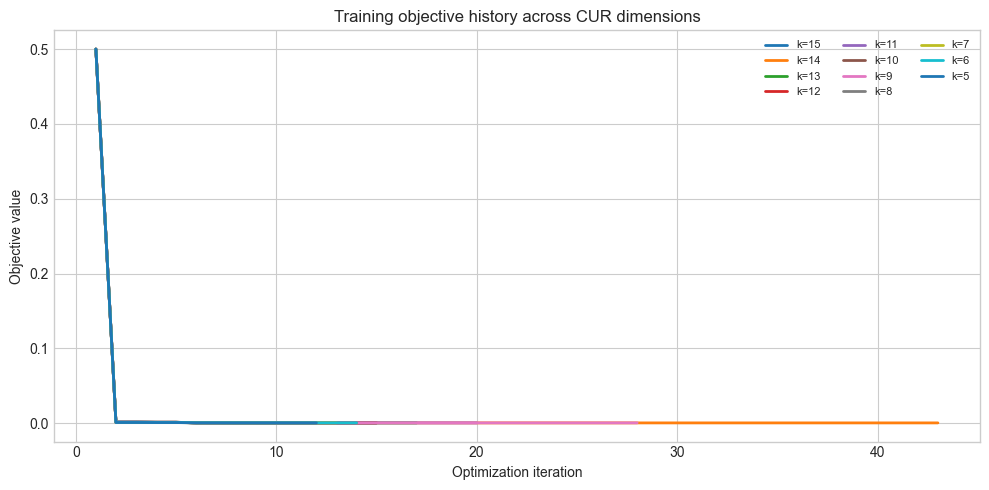

Saved loss chart to D:\kiet\hk6\big_data\final\2526-HK2-MMDS-CK\final_2_523K0011\Source\Task02\task02_loss_curves.png


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
for dimension, loss_history in sorted(objective_histories.items(), reverse=True):
    ax.plot(
        range(1, len(loss_history) + 1),
        loss_history,
        linewidth=2,
        label=f"k={dimension}",
    )
ax.set_title("Training objective history across CUR dimensions")
ax.set_xlabel("Optimization iteration")
ax.set_ylabel("Objective value")
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
fig.savefig(LOSS_CHART_PATH, dpi=220, bbox_inches="tight")
plt.show()
print("Saved loss chart to", LOSS_CHART_PATH)
assert LOSS_CHART_PATH.exists()


## 11. Plot Train/Test RMSE And Preview Embeddings


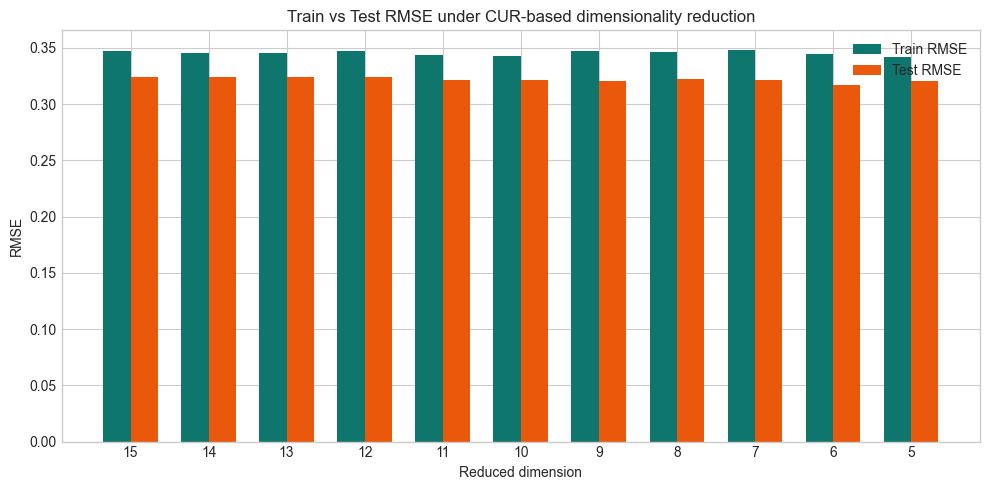

Saved RMSE comparison chart to D:\kiet\hk6\big_data\final\2526-HK2-MMDS-CK\final_2_523K0011\Source\Task02\task02_twin_bars.png
Best configuration based on test RMSE:


,dimension,train_rmse,test_rmse,selected_columns,selected_rows,objective_iterations
9,6,0.344467,0.316931,"[14, 0, 3, 11, 8, 5]","[3799, 3801, 3800, 3798, 3930, 3935]",14


Preview of the inferred row embedding at k=5:


,f_1,f_2,f_3,f_4,f_5
0,27.897072,28.20284,36.680242,36.840207,37.010797
1,27.897072,28.20284,36.680242,36.840207,37.010797
2,27.897072,28.20284,36.680242,36.840207,37.010797
3,27.897072,28.20284,36.680242,36.840207,37.010797
4,27.897072,28.20284,36.680242,36.840207,37.010797


In [11]:
dimensions = results_df["dimension"].tolist()
x_positions = np.arange(len(dimensions))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_positions - width / 2, results_df["train_rmse"], width=width, label="Train RMSE", color="#0f766e")
ax.bar(x_positions + width / 2, results_df["test_rmse"], width=width, label="Test RMSE", color="#ea580c")
ax.set_xticks(x_positions)
ax.set_xticklabels(dimensions)
ax.set_xlabel("Reduced dimension")
ax.set_ylabel("RMSE")
ax.set_title("Train vs Test RMSE under CUR-based dimensionality reduction")
ax.legend()
fig.tight_layout()
fig.savefig(BAR_CHART_PATH, dpi=220, bbox_inches="tight")
plt.show()
print("Saved RMSE comparison chart to", BAR_CHART_PATH)
assert BAR_CHART_PATH.exists()

best_row = results_df.sort_values("test_rmse").iloc[0]
print("Best configuration based on test RMSE:")
display(pd.DataFrame([best_row]))

print("Preview of the inferred row embedding at k=5:")
display(embedding_previews[5].head())


## 12. Release Spark Resources


In [12]:
train_df.unpersist()
test_df.unpersist()
sample_df.unpersist()
spark.stop()
